In [1]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
class ChemicalSpecies(object):
    '''define the class of chemical species'''
    
    def __init__(self, name, count):
        self.name=name
        self.count=count
        

        
class Reaction(object):
    '''define the class of chemical reactions'''
    
    def __init__(self,reactant_list, product_list, coefficient_dic, reconstant):
        self.reactant_list=reactant_list
        self.product_list=product_list
        self.coefficient_dic=coefficient_dic
        self.reaction_constant=reconstant
        
        
    def get_propensity(self):
        '''calculate the propensity of the chemical reaction'''
        k=1
        for i in self.reactant_list:
            k=k*i.count**self.coefficient_dic[i.name]
            
        propensity=self.reaction_constant*k
        return propensity
          
        
    def execute(self):
        '''calculate the molecular count of reactants and products after the reaction has been executed'''
        for i in self.reactant_list:
            i.count-=self.coefficient_dic[i.name]
            
        for j in self.product_list:
            j.count+=self.coefficient_dic[j.name]
            
        return self.reactant_list,self.product_list
    
    
    
class System(object):
    '''define the class of chemical system'''
    
    def __init__(self, reaction_list, chemical_list):
        self.reaction_list=reaction_list
        self.chemical_list=chemical_list
    
    
    def run_firstreaction(self,chemicals=None):
        '''Use the First Reaction Method to simulate one reaction step of the system with 5 reactions in Gibson et al'''
    
        rx1,rx2,rx3,rx4,rx5=self.reaction_list   # use rx1~rx5 to store the 5 chemical reactions
        
        if chemicals==None:  
            h,s,j,k,l,m,n=self.chemical_list  #give the initial value of h~n
        else:
            h,s,j,k,l,m,n=chemicals   # when run_firstreaction has been run, update the value of h~n

        in_equilibrium = False   # a marker to determine whether the system has reached equilibrium
        prop1=rx1.get_propensity()
        prop2=rx2.get_propensity()
        prop3=rx3.get_propensity()
        prop4=rx4.get_propensity()
        prop5=rx5.get_propensity()
        
        prop_list=[prop1,prop2,prop3,prop4,prop5]
        tau_list=[]
        
        for i in prop_list:
            if i==0:
                tau_list.append(np.inf)
            else:
                tau_list.append(((1/i)*np.log(1/(1-np.random.random()))))
        
        
        if prop_list!=[0,0,0,0,0]:  # if prop_list!=[0,0,0,0,0], the system did not reach equilibrium
            tau=min(tau_list)
            u=np.argmin(tau_list)
            
            if u==0:
                [h,s],[j]=rx1.execute()
            elif u==1:
                [s,j],[k]=rx2.execute()
            elif u==2:
                [k,l],[l,m]=rx3.execute()
            elif u==3:
                [m],[k,n]=rx4.execute()
            else:
                [l,n],[h]=rx5.execute()
            
        elif prop_list==[0,0,0,0,0]: # if tau_list=[0,0,0,0,0], the system has reached equilibrium
            in_equilibrium = True
            tau=np.inf
        
        else:
            print("Error: negative propensities.")
        
        species_list=[h,s,j,k,l,m,n]        
        
        return species_list, tau, in_equilibrium

        
        
    def stimulate(self,start_time, end_time):
        '''Stimulate the reactions during a given time period from start_time to end_time'''
        
        t0=start_time    # will be used to store the reaction time, and the initial vaule of it is the stimulation start time
        t_list=[start_time] # will be used to store t0, and the first element is the stimulation start time
        
        chem_list=[self.chemical_list] # will be used to store the chemical species after each round of run_firstreaction, and
                                     # the first element is the initial value of the chemical species
        
        chemcount_list=[] #will be used to store the molecular count of chemical species after each each round of run_firstreaction
        totalcount_list=[] # will be used to store the chemcount_list after each round of run_firstreaction
        
        for i in self.chemical_list:
            chemcount_list.append(i.count)  # the elements in first chemcount_list is the initial value of chemical species
        totalcount_list.append(chemcount_list) # store the first chemcount_list in totalcount_list
        
        equilibrium=False
        
        
        species_list, t, equilibrium=self.run_firstreaction()  # since for the first round of run_firstreaction, the value of 
                                                                # chemical species was from the self.chemical_list,(following 
                                                                # round use the previous calculation result of run_firstreaction
        t0+=t  # update t0
    
        t_list.append(t0) # after first round of run_firstreaction, store the updated t0 to t_list
        chem_list.append(species_list) # after first round of run_firstreaction, store the updated species_list to chem_list
                                        # the species_list here will be used for second round of run_firstreaction, and so forth.
        chemcount_list=[]
        for i in species_list:    # after first round of run_firstreaction, store the updated molecular count of chemical 
            chemcount_list.append(i.count) # species into chemcount_list
        
        totalcount_list.append(chemcount_list)   # store the chemcount_list into totalcount_list
            
        
        while t0<end_time:   # when t0<end_time (stimulation ending time), run the while loop
            species_list, t, equilibrium=self.run_firstreaction(species_list) # use previous species_list as input to run the 
                                                                            # run_directmethod.
            if t!=np.inf:  # t!=np.inf means prob_list!=[0,0,0,0,0], the system has not reached equilibrium
                t0+=t  # after each round of run_firstreaction update t0
                t_list.append(t0) # after each round of run_firstreaction, store the updated t0 to t_list
                chem_list.append(species_list) #store the updated species_list to chem_list,the species_list here will be used for
                                            #  the next round of run_firstreaction.
                    
                chemcount_list=[]   # after each round of run_firstreaction, store the updated molecular count of chemical
                for i in species_list:   # species into chemcount_list
                    chemcount_list.append(i.count)
                totalcount_list.append(chemcount_list)      # store the chemcount_list into totalcount_list

            else: # t=0 means sum(prob_list)==0, the system has reached equilibrium
                equilibrium=True
                break
            
        return np.array(t_list), np.array(totalcount_list), equilibrium
    
    
    
    def display(self, start_time, end_time, time):
        '''get the system state (molecular count of each chemical) at a given time point'''
        
        td,c,s=self.stimulate(start_time,end_time) # run the stimulate method and store the results in td, c and s
        
        if time<td[-1]:#if the given time is smaller then td[-1](the equilibrium time), it means the system has not reached 
            n=len(td)   # equilirium
            for i in range(n): # from the first element in td to search the elements which time is between them.
                if time>=td[i] and time<td[i+1]: # then get the corresponding element in c, this system state at given time
                    system_state=c[i]            # has the same molecular counts with this element
                    break
                   
        else:  # if the given time is larger than td[-1](the equilibrium time), it means the system has reached equilirium
            system_state=c[-1]  # just give the last element in c (the equilibrium state) to system_state

        print(list(zip(td,c)))
        print("The system state at time: {0} is: {1}".format(time,system_state))
        plt.plot(td,c)
     

([<__main__.ChemicalSpecies object at 0x0000000006BE6D30>, <__main__.ChemicalSpecies object at 0x0000000006BE6AC8>, <__main__.ChemicalSpecies object at 0x0000000006BE6C18>, <__main__.ChemicalSpecies object at 0x0000000006BE65C0>, <__main__.ChemicalSpecies object at 0x0000000006BE69B0>, <__main__.ChemicalSpecies object at 0x0000000006BB0400>, <__main__.ChemicalSpecies object at 0x0000000006BB0470>], 0.004288827860086543, False)
[(1.0, array([ 7, 14,  8, 12,  8,  3,  4])), (1.0008687857018412, array([ 6, 13,  9, 12,  8,  3,  4])), (1.0012624979597138, array([ 6, 13,  9, 13,  8,  2,  5])), (1.0036089145038729, array([ 6, 12,  8, 14,  8,  2,  5])), (1.004798200147867, array([ 6, 11,  7, 15,  8,  2,  5])), (1.0054895903308292, array([ 6, 11,  7, 14,  8,  3,  5])), (1.0061731853846518, array([ 7, 11,  7, 14,  7,  3,  4])), (1.006439913758618, array([ 6, 10,  8, 14,  7,  3,  4])), (1.0069060081752963, array([ 6, 10,  8, 13,  7,  4,  4])), (1.0096244960880696, array([ 6,  9,  7, 14,  7,  4,  4

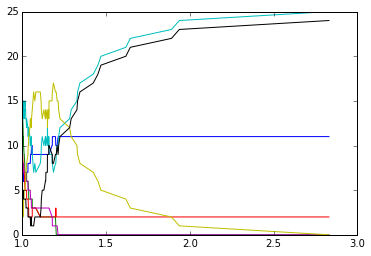

In [9]:
a=ChemicalSpecies('A',6)
b=ChemicalSpecies('B',14)
c=ChemicalSpecies('C',8)
d=ChemicalSpecies('D',12)
e=ChemicalSpecies('E',9)
f=ChemicalSpecies('F',3)
g=ChemicalSpecies('G',5)

chemical_list=[a,b,c,d,e,f,g]

rx1=Reaction([a, b],[c],{a.name:1,b.name:1,c.name:1},1)
rx2=Reaction([b, c],[d],{b.name:1,c.name:1,d.name:1},2)
rx3=Reaction([d,e],[e,f],{d.name:1,e.name:1,e.name:1,f.name:1},3)
rx4=Reaction([f],[d,g],{f.name:1,d.name:1,g.name:1},4)
rx5=Reaction([e, g],[a],{e.name:1,g.name:1,a.name:1},5)

reaction_list=[rx1,rx2,rx3,rx4,rx5]


system= System(reaction_list,chemical_list)
s=system.run_firstreaction()
print(s)


# w=system.stimulate(1,5)
# print(w)

v=system.display(1,5,1.5)
print(v)
